# VQE for Molecular Energy

Finding the ground-state energy of H₂ with a variational quantum eigensolver, and
checking it against the two classical baselines that make the result meaningful.

Companion to [`tutorials/01-simulation/01-vqe-molecular-energy.md`](../tutorials/01-simulation/01-vqe-molecular-energy.md).

**Requires:** `pip install -e ".[qiskit]"`. The arbitrary-bond-length section also
needs `pip install -e ".[nature]"`.

## 1. The Hamiltonian

The ground-state energy is the lowest eigenvalue of the molecular electronic
Hamiltonian. For H₂ in an STO-3G basis, a parity mapping with two-qubit reduction
brings it down to **two qubits**.

One thing trips up every comparison against published numbers: the qubit operator
encodes the *electronic* energy only. Nuclear repulsion has to be added back.

In [1]:
from qprac_lab.algorithms.simulation.hamiltonian_utils import build_h2_hamiltonian

hamiltonian = build_h2_hamiltonian(bond_length_angstrom=0.735)

print(f"qubits:              {hamiltonian.num_qubits}")
print(f"source:              {hamiltonian.source}")
print(f"electronic energy:   {hamiltonian.exact_electronic_energy():+.9f} Ha   <- the operator alone")
print(f"nuclear repulsion:   {hamiltonian.nuclear_repulsion_energy:+.9f} Ha")
print(f"total (FCI):         {hamiltonian.exact_total_energy():+.9f} Ha   <- the quoted number")

qubits:              2
source:              qiskit_nature_pyscf
electronic energy:   -1.857275030 Ha   <- the operator alone
nuclear repulsion:   +0.719968994 Ha
total (FCI):         -1.137306036 Ha   <- the quoted number


The `XX` term is the whole problem. Every `Z` term is diagonal, so a single
computational basis state diagonalises them — that state *is* Hartree-Fock. Only
`XX` mixes determinants, and that mixing is electron correlation.

In [2]:
for pauli, coefficient in zip(hamiltonian.qubit_operator.paulis.to_labels(),
                              hamiltonian.qubit_operator.coeffs, strict=True):
    print(f"  {pauli}  {coefficient.real:+.9f}")

  II  -1.052373246
  IZ  +0.397937425
  ZI  -0.397937425
  ZZ  -0.011280104
  XX  +0.180931200


## 2. The two classical baselines

Both are mandatory, and they answer different questions:

- **Hartree-Fock** is the bar to beat. Below it, VQE is doing something.
- **Exact diagonalisation** is the floor. Below it, VQE is doing something *wrong* —
  the variational principle guarantees no trial state can go under it.

In [3]:
exact = hamiltonian.exact_total_energy()
hartree_fock = hamiltonian.hartree_fock_total_energy()

print(f"Hartree-Fock:            {hartree_fock:+.9f} Ha")
print(f"Exact diagonalisation:   {exact:+.9f} Ha")
print(f"Correlation energy:      {hamiltonian.correlation_energy():+.9f} Ha  <- what VQE must recover")

Hartree-Fock:            -1.116998997 Ha
Exact diagonalisation:   -1.137306036 Ha
Correlation energy:      -0.020307039 Ha  <- what VQE must recover


## 3. Run VQE

The ansatz is the one-parameter UCC circuit: start in the Hartree-Fock state
`|01>`, then apply a single excitation. One parameter suffices because the
relevant subspace is two-dimensional.

At `theta = 0` the circuit *is* Hartree-Fock, so the optimisation provably starts
at the HF energy and can only improve.

In [4]:
from qprac_lab.algorithms.simulation.vqe_molecular_energy import run_vqe_molecular_energy_tutorial

result = run_vqe_molecular_energy_tutorial()

print(f"ansatz:                 {result.ansatz} ({result.num_parameters} parameter)")
print(f"objective evaluations:  {result.function_evaluations}")
print(f"optimal theta:          {result.best_theta:+.6f}")
print()
print(f"VQE energy:             {result.vqe_energy:+.9f} Ha")
print(f"exact:                  {result.exact_baseline_energy:+.9f} Ha")
print(f"absolute error:         {result.absolute_error:.2e} Ha")
print(f"chemical accuracy:      {result.chemical_accuracy_reached}  (threshold 1.6e-3 Ha)")
print(f"correlation recovered:  {result.correlation_recovery_fraction:.4%}")

ansatz:                 two_qubit_uccsd (1 parameter)
objective evaluations:  23
optimal theta:          +0.223500

VQE energy:             -1.137306035 Ha
exact:                  -1.137306036 Ha
absolute error:         5.59e-10 Ha
chemical accuracy:      True  (threshold 1.6e-3 Ha)
correlation recovered:  100.0000%


## 4. Convergence

Two panels, because one is not enough: the optimiser's early exploration spans a
far wider energy range than the converged region, so on a linear axis the part
that matters collapses onto the reference line.

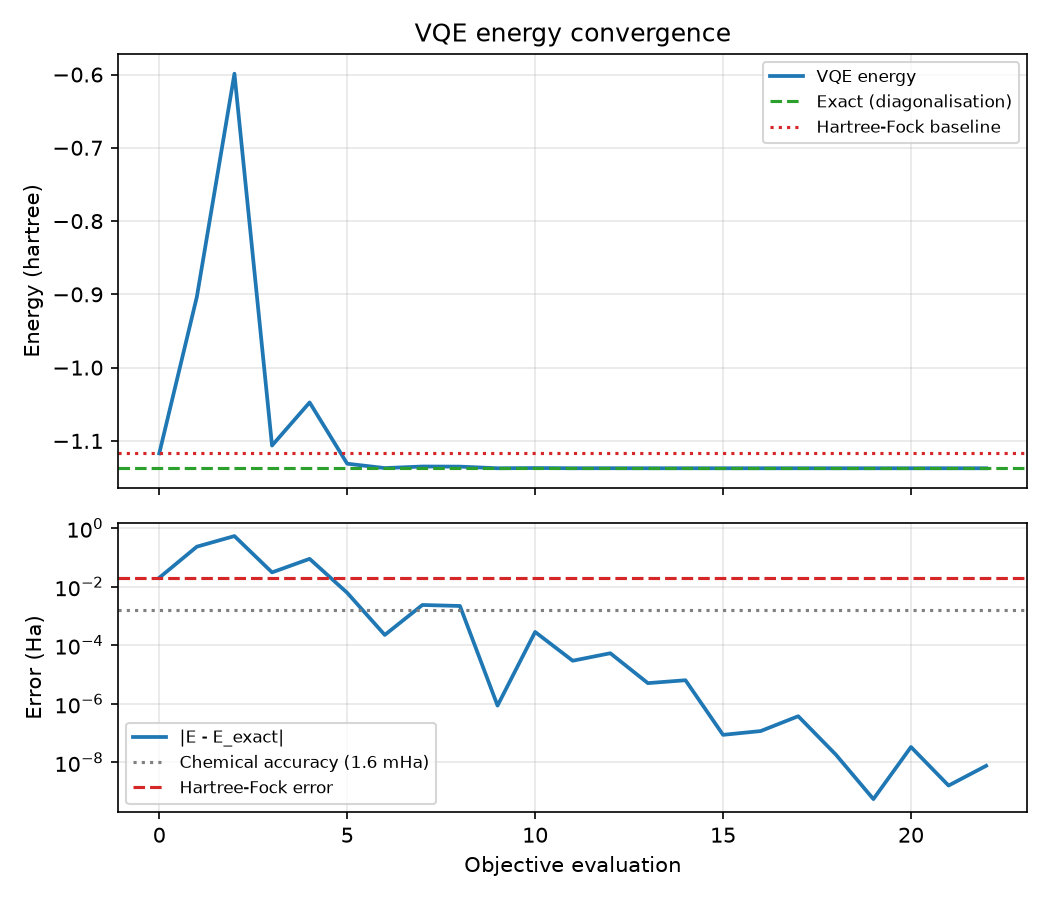

In [5]:
from qprac_lab.visualization.tutorial_outputs import plot_energy_convergence
from IPython.display import Image

Image(plot_energy_convergence(
    result.convergence_history,
    output_path="../results/nb_vqe_convergence.png",
    exact_energy=result.exact_baseline_energy,
    hartree_fock_energy=result.hartree_fock_baseline_energy,
))

## 5. Where VQE actually earns its cost

Near equilibrium, Hartree-Fock is off by 20 mHa and is often good enough. The
interesting regime is a *stretched* bond: restricted HF cannot describe bond
dissociation at all, because one determinant cannot represent the
two-configuration character of a breaking bond.

(Needs the `nature` extra; returns an empty list without it.)

In [6]:
if result.dissociation_curve:
    print(f"{'R (A)':>7} {'VQE':>12} {'exact':>12} {'HF':>12} {'HF error':>10}")
    for row in result.dissociation_curve:
        hf_error = abs(row["hartree_fock_energy"] - row["exact_energy"])
        print(f"{row['bond_length_angstrom']:>7.3f} {row['vqe_energy']:>12.6f} "
              f"{row['exact_energy']:>12.6f} {row['hartree_fock_energy']:>12.6f} {hf_error:>10.3f}")
else:
    print('dissociation curve needs: pip install -e ".[nature]"')

  R (A)          VQE        exact           HF   HF error
  0.500    -1.055160    -1.055160    -1.042996      0.012
  0.735    -1.137306    -1.137306    -1.116999      0.020
  1.000    -1.101150    -1.101150    -1.066109      0.035
  1.500    -0.998149    -0.998149    -0.910874      0.087
  2.000    -0.948641    -0.948641    -0.783793      0.165
  2.500    -0.936055    -0.936055    -0.702944      0.233


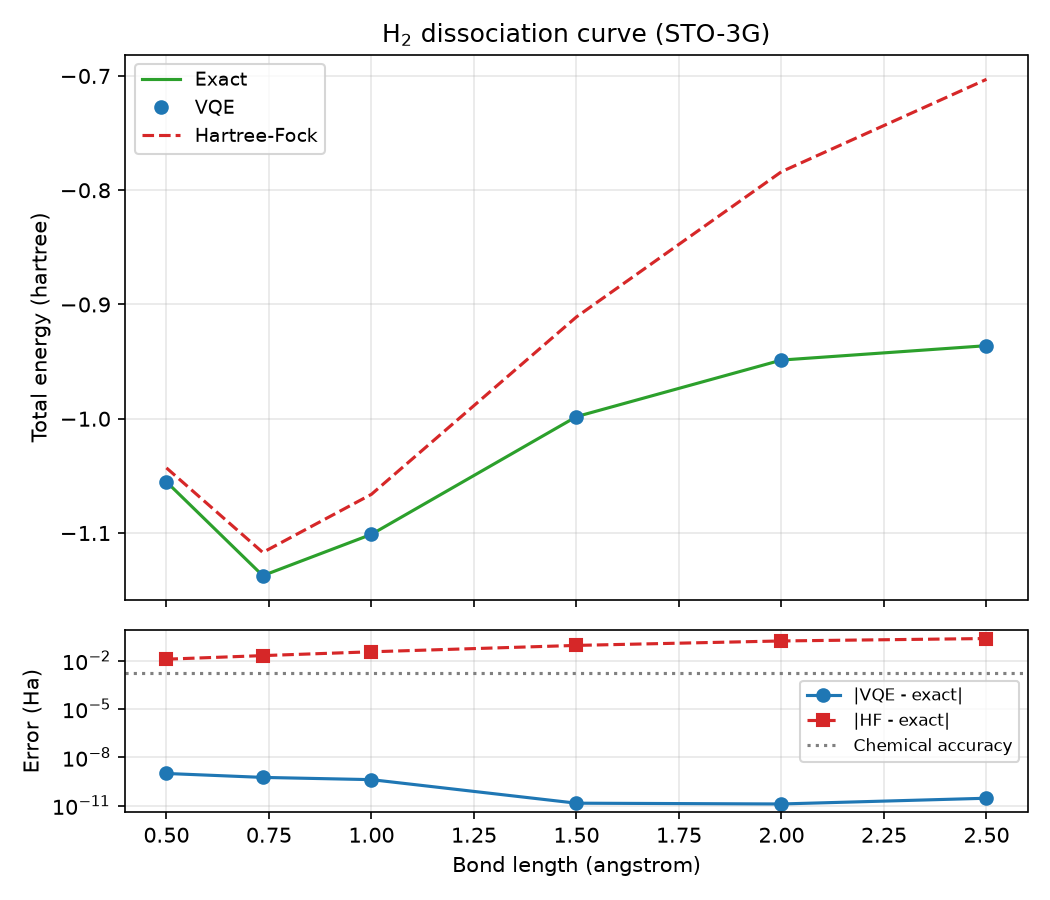

In [7]:
from qprac_lab.visualization.tutorial_outputs import plot_dissociation_curve

path = plot_dissociation_curve(result.dissociation_curve, output_path="../results/nb_vqe_curve.png")
Image(path) if path else print("skipped")

## 6. What noise does to all of this

Everything above is an ideal simulator. VQE is the most noise-fragile method in
this project, and it is worth seeing why in one table.

`light` is *optimistic* hardware — better than most devices today.

In [8]:
rows = []
for noise in [None, "light", "moderate", "heavy"]:
    noisy = run_vqe_molecular_energy_tutorial(
        backend="aer", noise=noise, include_dissociation_curve=False, maxiter=150,
    )
    rows.append((noise or "ideal", noisy.vqe_energy, noisy.absolute_error,
                 noisy.chemical_accuracy_reached))

print(f"{'noise':>10} {'energy (Ha)':>14} {'error (Ha)':>12} {'chem. accuracy':>15}")
for name, energy, error, reached in rows:
    print(f"{name:>10} {energy:>14.6f} {error:>12.2e} {str(reached):>15}")

     noise    energy (Ha)   error (Ha)  chem. accuracy
     ideal      -1.137306     6.90e-11            True
     light      -1.135129     2.18e-03           False
  moderate      -1.125989     1.13e-02           False
     heavy      -1.099976     3.73e-02           False


**Even the optimistic preset misses chemical accuracy** — on a *two-qubit*
circuit of depth ~10, about as small as a useful chemistry circuit gets. The
ideal simulator's ten-decimal-place result loses seven of them to light noise.

Any VQE number quoted without a noise model is a statement about arithmetic, not
chemistry. Full comparison across all four tutorials:
[`tutorials/05-benchmarking/noise_benchmark.md`](../tutorials/05-benchmarking/noise_benchmark.md).

## When not to use VQE

- **Near equilibrium with a cheap alternative.** CCSD(T) gets this same answer in
  milliseconds on a laptop.
- **On current hardware, if you need chemical accuracy.** See the table above.
- **With large hardware-efficient ansätze.** `efficient_su2` needs 12 parameters
  for 2 qubits versus 1 here; that growth plus barren plateaus is the central
  open obstacle.